In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../Day10/feature_engineered_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape: (51289, 29)

First 5 rows:
      sales  quantity  discount    profit  shipping_cost      year  \
0  0.331231 -0.647987 -0.673206  0.444306       0.158536 -1.617213   
1 -0.259459 -0.209148 -0.202086  0.042389      -0.290705 -1.617213   
2 -0.370213  0.229691 -0.673206  0.005720      -0.317757 -1.617213   
3 -0.413284 -0.209148  1.682395 -0.313588      -0.376225 -1.617213   
4 -0.271765  0.668530 -0.202086  0.052330      -0.378319 -1.617213   

   shipping_days  profit_margin  sales_per_shipping_day  profit_per_sales  \
0       0.595934       0.456122                0.030541          0.473625   
1       1.752380       0.542131               -0.300409          0.560493   
2       0.017711       0.860846               -0.311649          0.888330   
3       0.017711      -1.341358               -0.337875         -1.399300   
4       1.752380       0.608568               -0.305092          0.629921   

   ...  region_Central  region_Central Asia  region_E

In [3]:
print("All features in the dataset:")
print(list(df.columns))

print("\nNumber of features:", len(df.columns))

All features in the dataset:
['sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'year', 'shipping_days', 'profit_margin', 'sales_per_shipping_day', 'profit_per_sales', 'category_Furniture', 'category_Office Supplies', 'category_Technology', 'segment_Consumer', 'segment_Corporate', 'segment_Home Office', 'region_Africa', 'region_Canada', 'region_Caribbean', 'region_Central', 'region_Central Asia', 'region_EMEA', 'region_East', 'region_North', 'region_North Asia', 'region_Oceania', 'region_South', 'region_Southeast Asia', 'region_West']

Number of features: 29


In [4]:
X = df.drop(columns=["profit", "profit_margin", "profit_per_sales"])
y = df["profit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline Model Performance")
print("--------------------------")
print("MAE:", round(baseline_mae, 4))
print("R²:", round(baseline_r2, 4))

Baseline Model Performance
--------------------------
MAE: 0.3428
R²: 0.3611


In [5]:
X_reduced = X.drop(columns=["sales"])

print("Original number of features:", X.shape[1])
print("Features after removing sales:", X_reduced.shape[1])

print("\nRemoved feature: sales")

Original number of features: 26
Features after removing sales: 25

Removed feature: sales


In [6]:
X_reduced_train, X_reduced_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

reduced_model = LinearRegression()
reduced_model.fit(X_reduced_train, y_train)

reduced_pred = reduced_model.predict(X_reduced_test)

reduced_mae = mean_absolute_error(y_test, reduced_pred)
reduced_r2 = r2_score(y_test, reduced_pred)

print("Model Performance After Removing Sales")
print("---------------------------------------")
print("MAE:", round(reduced_mae, 4))
print("R²:", round(reduced_r2, 4))

Model Performance After Removing Sales
---------------------------------------
MAE: 0.3525
R²: 0.3029


In [7]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "R²"],
    "Before Removing Sales": [baseline_mae, baseline_r2],
    "After Removing Sales": [reduced_mae, reduced_r2]
})

print("Performance Comparison")
print("----------------------")
print(comparison.round(4))

Performance Comparison
----------------------
  Metric  Before Removing Sales  After Removing Sales
0    MAE                 0.3428                0.3525
1     R²                 0.3611                0.3029


In [8]:
mae_change = reduced_mae - baseline_mae
r2_change = reduced_r2 - baseline_r2

print("Performance Change After Removing Sales")
print("-----------------------------------------")
print("MAE Change:", round(mae_change, 4))
print("R² Change:", round(r2_change, 4))

print("\nInterpretation:")

if r2_change < 0:
    print("R² decreased after removing sales.")
    print("This indicates that sales was an important feature for predicting profit.")
else:
    print("R² did not decrease after removing sales.")

if mae_change > 0:
    print("MAE increased, meaning prediction error became larger.")
else:
    print("MAE did not increase.")

Performance Change After Removing Sales
-----------------------------------------
MAE Change: 0.0097
R² Change: -0.0583

Interpretation:
R² decreased after removing sales.
This indicates that sales was an important feature for predicting profit.
MAE increased, meaning prediction error became larger.


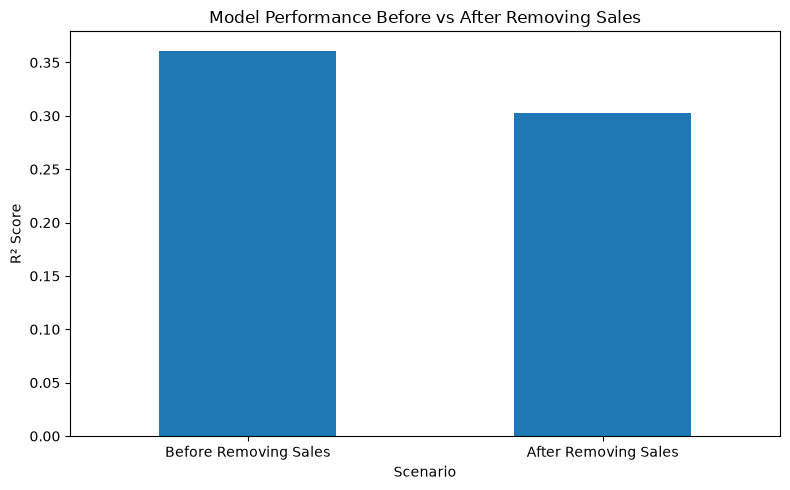

In [9]:
comparison_plot = pd.DataFrame({
    "Model": ["Before Removing Sales", "After Removing Sales"],
    "R² Score": [baseline_r2, reduced_r2]
})

comparison_plot.plot(
    x="Model",
    y="R² Score",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.title("Model Performance Before vs After Removing Sales")
plt.ylabel("R² Score")
plt.xlabel("Scenario")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "performance_before_after.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
print("SPRINT 2 REFLECTION")
print("-------------------")

print("\nWhat I learned:")
print("1. Machine learning models depend on the quality and availability of features.")
print("2. Removing an important feature can reduce model performance.")
print("3. The model was able to continue making predictions using the remaining features.")
print("4. Comparing before and after performance helps measure the impact of changing constraints.")
print("5. Real-world ML systems need to adapt when data or business requirements change.")

print("\nDay 14 Conclusion:")
print("The model adapted to the loss of the sales feature, but its performance decreased.")
print("This shows that important features can have a significant impact on predictions.")

SPRINT 2 REFLECTION
-------------------

What I learned:
1. Machine learning models depend on the quality and availability of features.
2. Removing an important feature can reduce model performance.
3. The model was able to continue making predictions using the remaining features.
4. Comparing before and after performance helps measure the impact of changing constraints.
5. Real-world ML systems need to adapt when data or business requirements change.

Day 14 Conclusion:
The model adapted to the loss of the sales feature, but its performance decreased.
This shows that important features can have a significant impact on predictions.


In [11]:
comparison.to_csv("performance_comparison.csv", index=False)

print("Performance comparison saved successfully!")
print("\nSaved file: performance_comparison.csv")

Performance comparison saved successfully!

Saved file: performance_comparison.csv
